Episodio 5000/30000 | ε=0.082 | Reward medio últimos 1000: 0.000
Episodio 10000/30000 | ε=0.050 | Reward medio últimos 1000: 0.000
Episodio 15000/30000 | ε=0.050 | Reward medio últimos 1000: 0.000
Episodio 20000/30000 | ε=0.050 | Reward medio últimos 1000: 0.001
Episodio 25000/30000 | ε=0.050 | Reward medio últimos 1000: 0.000
Episodio 30000/30000 | ε=0.050 | Reward medio últimos 1000: 0.000


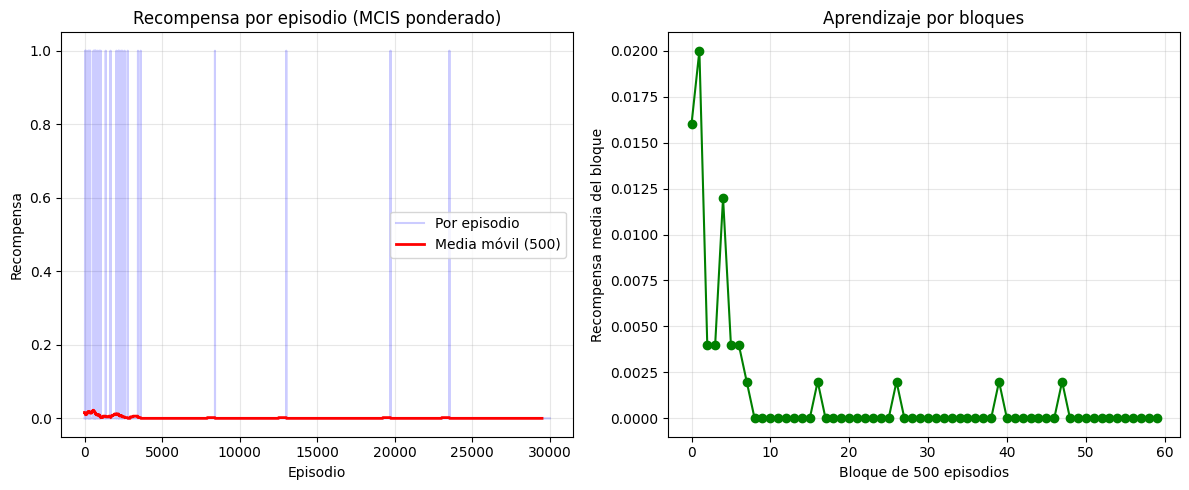


✅ Tasa de éxito de la política aprendida: 0.0%

Política aprendida (← 0, ↓ 1, → 2, ↑ 3):


🧊 ← ← ← 
← 🧊 ← 🧊 
← ← ← 🧊 
🧊 ← ↓ 🎯 


In [1]:
# ============================================================
# Celda 1: Instalación e imports
# ============================================================
!pip install gymnasium matplotlib numpy -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Para reproducibilidad
np.random.seed(42)

# ============================================================
# Celda 2: Entorno y parámetros
# ============================================================
# FrozenLake 4x4 resbaloso (stochastic). 16 estados, 4 acciones.
env = gym.make('FrozenLake-v1', is_slippery=True, map_name="4x4")

NUM_EPISODES = 30000
GAMMA = 1.0          # episodios finitos -> gamma = 1
EPSILON_START = 1.0  # mucha exploración al inicio
EPSILON_END = 0.05
EPSILON_DECAY = 0.9995

# ============================================================
# Celda 3: Inicialización de Q, C y π
# ============================================================
# Q(s,a): valor acción-estado
# C(s,a): suma acumulada de pesos (para el promedio ponderado)
# pi(s): política objetivo (determinista, greedy respecto a Q)

Q = defaultdict(lambda: np.zeros(env.action_space.n))
C = defaultdict(lambda: np.zeros(env.action_space.n))

def greedy_policy(s):
    """Política objetivo π: determinista, greedy."""
    return int(np.argmax(Q[s]))

def pi_prob(s, a):
    """π(a|s): 1 si es la acción greedy, 0 si no."""
    return 1.0 if a == greedy_policy(s) else 0.0

def mu_prob(s, a, epsilon):
    """μ(a|s): política ε-greedy (soft)."""
    nA = env.action_space.n
    if a == greedy_policy(s):
        return 1.0 - epsilon + epsilon / nA
    else:
        return epsilon / nA

# ============================================================
# Celda 4: Generación de episodio bajo μ (ε-greedy)
# ============================================================
def generate_episode(epsilon):
    episode = []
    state, _ = env.reset()
    while True:
        # Elegir acción según μ (ε-greedy)
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # exploración pura
        else:
            action = greedy_policy(state)       # explotación

        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))

        if terminated or truncated:
            break
        state = next_state
    return episode

# ============================================================
# Celda 5: Bucle principal de entrenamiento MCIS
# ============================================================
rewards_per_episode = []
epsilon = EPSILON_START

for ep in range(NUM_EPISODES):
    # 1. Generar episodio con μ (soft)
    episode = generate_episode(epsilon)
    T = len(episode)

    G = 0.0
    W = 1.0

    # 2. Recorrer hacia atrás
    for t in range(T - 1, -1, -1):
        St, At, Rt = episode[t]
        G = GAMMA * G + Rt
        C[St][At] += W
        Q[St][At] += (W / C[St][At]) * (G - Q[St][At])
        # π(St) se actualiza implícitamente porque greedy_policy lee Q

        # Siguiente estado para calcular π(A_{t+1}|S_{t+1})
        if t > 0:
            St_next = episode[t - 1][0]
            At_next = episode[t - 1][1]
            W = W * pi_prob(St_next, At_next) / mu_prob(St_next, At_next, epsilon)
        else:
            # t == 0: no hay más pasos hacia atrás, pero aún podemos
            # multiplicar por el peso del primer paso para completar
            # (en realidad ya no se usa W después, pero lo dejamos claro)
            pass

        # Si W == 0, salimos: a partir de aquí π no habría tomado esa acción
        if W == 0.0:
            break

    # 3. Registrar recompensa del episodio (última Rt es 1 si llegó a meta)
    rewards_per_episode.append(episode[-1][2])

    # 4. Decaimiento de epsilon
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    # Progreso
    if (ep + 1) % 5000 == 0:
        avg_last = np.mean(rewards_per_episode[-1000:])
        print(f"Episodio {ep+1}/{NUM_EPISODES} | ε={epsilon:.3f} | "
              f"Reward medio últimos 1000: {avg_last:.3f}")

# ============================================================
# Celda 6: Curva de recompensa promedio (ventana móvil)
# ============================================================
def moving_average(x, w=500):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(12, 5))

# Recompensa cruda por episodio
plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode, alpha=0.2, color='blue', label='Por episodio')
plt.plot(moving_average(rewards_per_episode, 500), color='red',
         linewidth=2, label='Media móvil (500)')
plt.xlabel('Episodio')
plt.ylabel('Recompensa')
plt.title('Recompensa por episodio (MCIS ponderado)')
plt.legend()
plt.grid(alpha=0.3)

# Media por bloques de 500 episodios
plt.subplot(1, 2, 2)
block_size = 500
blocks = [np.mean(rewards_per_episode[i:i+block_size])
          for i in range(0, len(rewards_per_episode), block_size)]
plt.plot(blocks, marker='o', color='green')
plt.xlabel(f'Bloque de {block_size} episodios')
plt.ylabel('Recompensa media del bloque')
plt.title('Aprendizaje por bloques')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Celda 7: Evaluación de la política aprendida (1000 episodios)
# ============================================================
def evaluate_policy(n_eval=1000):
    successes = 0
    for _ in range(n_eval):
        state, _ = env.reset()
        done = False
        while not done:
            action = greedy_policy(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            if terminated and reward == 1.0:
                successes += 1
                break
    return successes / n_eval

success_rate = evaluate_policy()
print(f"\n✅ Tasa de éxito de la política aprendida: {success_rate*100:.1f}%")

# ============================================================
# Celda 8: Visualización de la política sobre el mapa
# ============================================================
ARROWS = {0: '←', 1: '↓', 2: '→', 3: '↑'}
SPECIAL = {0: '🧊', 5: '🧊', 7: '🧊', 11: '🧊',
           12: '🧊', 15: '🎯'}  # hielo y meta

print("\nPolítica aprendida (← 0, ↓ 1, → 2, ↑ 3):")
print("\n")
for row in range(4):
    line = ""
    for col in range(4):
        s = row * 4 + col
        if s in SPECIAL:
            line += SPECIAL[s] + " "
        else:
            a = greedy_policy(s)
            line += ARROWS[a] + " "
    print(line)